In [ ]:
# Cài đặt thư viện xử lý ảnh và mô hình AI của Hugging Face
# !pip install -q transformers torch torchvision pillow tqdm

In [ ]:
import zipfile
import os

# Sửa lại đường dẫn chuẩn theo vị trí file của bạn
# zip_path = '/content/drive/MyDrive/data-collection/total.zip'
zip_path = './total.zip'
extract_path = './my_palmprint_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Đã giải nén xong!")

# Kiểm tra xem cấu trúc thư mục con bên trong đã đúng chưa
print("Các thư mục người dùng tìm thấy:")
print(os.listdir(extract_path)[:5])

Đã giải nén xong!
Các thư mục người dùng tìm thấy:
['total']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Thiết bị: cuda
Dataset: 21977 ảnh | 231 lớp hợp lệ

 BẮT ĐẦU HUẤN LUYỆN: MOBILENET_V2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 188MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [ 1/10]  Loss: 0.1243  Gap: 0.5009
  Epoch [ 2/10]  Loss: 0.0457  Gap: 0.6699
  Epoch [ 3/10]  Loss: 0.0290  Gap: 0.6414
  Epoch [ 4/10]  Loss: 0.0228  Gap: 0.6783
  Epoch [ 5/10]  Loss: 0.0183  Gap: 0.7183
  Epoch [ 6/10]  Loss: 0.0150  Gap: 0.6730
  Epoch [ 7/10]  Loss: 0.0129  Gap: 0.7309
  Epoch [ 8/10]  Loss: 0.0129  Gap: 0.7477
  Epoch [ 9/10]  Loss: 0.0111  Gap: 0.7151
  Epoch [10/10]  Loss: 0.0099  Gap: 0.7660
Xong mobilenet_v2! Thời gian: 3266.4s | Params: 2.39M
Đã lưu model → mobilenet_v2_triplet.pth

 BẮT ĐẦU HUẤN LUYỆN: RESNET50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


  Epoch [ 1/10]  Loss: 0.0877  Gap: 0.5906
  Epoch [ 2/10]  Loss: 0.0268  Gap: 0.5973
  Epoch [ 3/10]  Loss: 0.0163  Gap: 0.7242
  Epoch [ 4/10]  Loss: 0.0139  Gap: 0.6960
  Epoch [ 5/10]  Loss: 0.0122  Gap: 0.7479
  Epoch [ 6/10]  Loss: 0.0109  Gap: 0.7474
  Epoch [ 7/10]  Loss: 0.0097  Gap: 0.7103
  Epoch [ 8/10]  Loss: 0.0097  Gap: 0.7075
  Epoch [ 9/10]  Loss: 0.0091  Gap: 0.7103
  Epoch [10/10]  Loss: 0.0100  Gap: 0.7503
Xong resnet50! Thời gian: 6150.1s | Params: 23.77M
Đã lưu model → resnet50_triplet.pth

 BẮT ĐẦU HUẤN LUYỆN: EFFICIENTNET_B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 97.9MB/s]


  Epoch [ 1/10]  Loss: 0.1156  Gap: 0.6460
  Epoch [ 2/10]  Loss: 0.0334  Gap: 0.6276
  Epoch [ 3/10]  Loss: 0.0194  Gap: 0.7148
  Epoch [ 4/10]  Loss: 0.0164  Gap: 0.7515
  Epoch [ 5/10]  Loss: 0.0143  Gap: 0.7502
  Epoch [ 6/10]  Loss: 0.0109  Gap: 0.7727
  Epoch [ 7/10]  Loss: 0.0102  Gap: 0.7905
  Epoch [ 8/10]  Loss: 0.0089  Gap: 0.7218
  Epoch [ 9/10]  Loss: 0.0081  Gap: 0.8109
  Epoch [10/10]  Loss: 0.0086  Gap: 0.8285
Xong efficientnet_b0! Thời gian: 3522.7s | Params: 4.17M
Đã lưu model → efficientnet_b0_triplet.pth

Đã lưu biểu đồ → model_comparison_curves.png


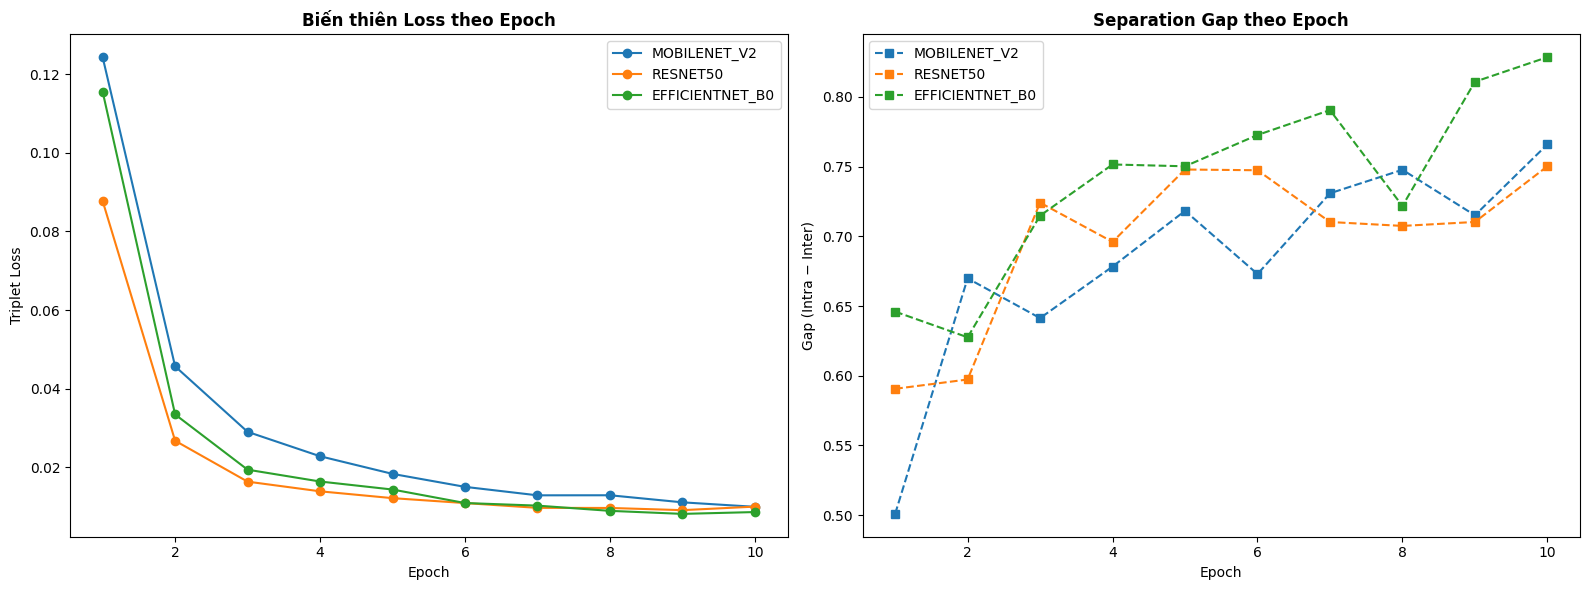


 BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH
Model Architecture  Parameters (M)  Train Time (seconds)  Final Separation Gap
      MOBILENET_V2            2.39                3266.4                0.7660
          RESNET50           23.77                6150.1                0.7503
   EFFICIENTNET_B0            4.17                3522.7                0.8285

Đã lưu bảng → model_comparison_results.csv


In [ ]:
# ── Cấu hình đường dẫn ──────────────────────────────────────
import sys, os

SCRIPT_PATH  = "train_model_comparison.py"  # đặt đúng thư mục chứa file
DATASET_PATH = "./my_palmprint_dataset/total"  # bạn đã giải nén sẵn
EPOCHS       = 10

# ── Ghi đè cấu hình vào script rồi chạy ─────────────────────
with open(SCRIPT_PATH, "r", encoding="utf-8") as f:
    code = f.read()

code = code.replace(
    'DATASET_PATH = "./my_palmprint_dataset/total"',
    f'DATASET_PATH = "{DATASET_PATH}"'
).replace(
    'EPOCHS        = 10',
    f'EPOCHS        = {EPOCHS}'
)

exec(code, {"__name__": "__main__"})